Project Analysis
📖 Problem Context  

This project is about analyzing marketing campaign data to understand customer acquisition better.  
It’s rooted in the Marketing Mix (4 Ps) concept:  
People (Demographics) → Age, education, marital status, income, etc.  
Product (Spending) → Customer expenditures on categories like wine, fruits, meat, gold, etc.  
Place (Channels) → Purchases through web, catalog, in-store.  
Promotion (Campaigns) → Customer response to marketing campaigns.  

The company wants to know:  
Which customers respond better to promotions?  
What patterns in demographics and spending drive acceptance?  
How do different sales channels and products perform?  

🎯 Problem Objective  
Your role (as data scientist) is to:  
Perform Exploratory Data Analysis (EDA) → find patterns and insights.  
Conduct Hypothesis Testing → validate assumptions about customer behavior.  
Generate Business Insights → recommendations for improving campaign strategy & acquisition.  

📂 Dataset Overview (marketing_data.csv)  
The dataset fields (from the data dictionary & problem statement) include:  
People  
ID, Year_Birth → customer’s year of birth  
Education, Marital_Status  
Income (some missing values)  
Kidhome, Teenhome → children at home  
Dt_Customer → date they enrolled  

Product (Spending)  
MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds → spending in last 2 years  

Place (Channels)  
NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumDealsPurchases  
NumWebVisitsMonth  

Promotion  
Response → accepted last campaign? (0/1)  
AcceptedCmp1 … AcceptedCmp5 → acceptance of past campaigns  
Complain → lodged complaint in last 2 years  

Extra Features  
Recency → days since last purchase  
Country  

📊 Business Context  
This company likely runs targeted campaigns (e.g., email promos, catalog offers, discounts) to encourage purchases.  
The data allows us to answer questions like:  
Are older people less likely to accept online campaigns?  
Do customers with children prefer online shopping due to time constraints?  
Are physical stores cannibalized by online/catalog channels?  
Does USA outperform other countries in purchase volume?  
Which products bring the most/least revenue?  
What customer segments (by age, children, education, complaints) behave differently?  

🧪 Hypotheses to Test (from problem statement)  
Age vs Place → Older customers prefer in-store.  
Children vs Channel → Customers with children prefer online.  
Cannibalization → Store sales cannibalized by other channels.  
Country Effect → USA customers buy more than others.  

🎯 End Goal  
At the end, we’ll have a Jupyter Notebook with:  
Clear EDA visualizations  
Hypothesis test results (with p-values & business interpretation)  
Insights for marketing strategy  

## Task 1 — Data Import & Initial Checks

In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
df = pd.read_csv("marketing_data.csv")

# Step 3: Basic Checks
print("Shape of dataset:", df.shape)
print("\nColumn names and data types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values summary:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe(include='all'))

Shape of dataset: (2240, 28)

Column names and data types:
ID                      int64
Year_Birth              int64
Education              object
Marital_Status         object
 Income                object
Kidhome                 int64
Teenhome                int64
Dt_Customer            object
Recency                 int64
MntWines                int64
MntFruits               int64
MntMeatProducts         int64
MntFishProducts         int64
MntSweetProducts        int64
MntGoldProds            int64
NumDealsPurchases       int64
NumWebPurchases         int64
NumCatalogPurchases     int64
NumStorePurchases       int64
NumWebVisitsMonth       int64
AcceptedCmp3            int64
AcceptedCmp4            int64
AcceptedCmp5            int64
AcceptedCmp1            int64
AcceptedCmp2            int64
Response                int64
Complain                int64
Country                object
dtype: object

First 5 rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP



Missing values summary:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

Descriptive statistics:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
count,2240.000000,2240.000000,2240,2240,2216,2240.000000,2240.000000,2240,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240
unique,NaN,NaN,5,8,1974,NaN,NaN,663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
top,NaN,NaN,Graduation,Married,"$7,500.00",NaN,NaN,8/31/12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP
freq,NaN,NaN,1127,864,12,NaN,NaN,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1095
mean,5592.159821,1968.805804,NaN,NaN,NaN,0.444196,0.506250,NaN,49.109375,303.935714,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375,NaN
std,3246.662198,11.984069,NaN,NaN,NaN,0.538398,0.544538,NaN,28.962453,336.597393,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391,NaN
min,0.000000,1893.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2828.250000,1959.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,24.000000,23.750000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,5458.500000,1970.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,49.000000,173.500000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,8427.750000,1977.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,74.000000,504.250000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


## Task 2 — Data Cleaning & Feature Engineering
- Fix column names (`Income`).
- Clean and convert Income to numeric.
- Handle missing values (group imputation).
- Remove unrealistic ages (before 1940).
- Feature engineering:
  - Age
  - Total_Children
  - Total_Spending
  - Total_Purchases

In [4]:
# Robust cleaning + feature engineering (handles weird column names)
import pandas as pd
import numpy as np

# Show exact column names (repr to reveal whitespace)
print("Columns (repr):")
for c in df.columns:
    print(repr(c))

# Strip whitespace (leading/trailing + non-breaking spaces) from column names
df.columns = [c.strip().replace('\u00A0','') if isinstance(c, str) else c for c in df.columns]

print("\nColumns after stripping (repr):")
for c in df.columns:
    print(repr(c))

# If Income still not present, show a shortlist of columns containing 'Income' substring
income_like = [c for c in df.columns if 'income' in str(c).lower()]
print("\nColumns with 'income' in name:", income_like)

# --- Normalize Income safely ---
# Show sample unique values before cleaning (first 10 non-null)
print("\nSample raw Income values (first 10 non-null):")
print(df[df.columns[df.columns.str.lower().str.contains('income')]].iloc[:,0].dropna().unique()[:10])

# Identify the exact income column name (after stripping)
income_col = income_like[0] if income_like else 'Income'
print("\nUsing income column:", income_col)

# Remove $ and , and convert to numeric (coerce errors -> NaN)
df[income_col] = df[income_col].astype(str).str.replace('[\$,]', '', regex=True).str.replace(',', '', regex=False)
df[income_col] = pd.to_numeric(df[income_col], errors='coerce')

# Check how many nulls now
print("\nMissing in income after coercion:", df[income_col].isnull().sum())

# Impute missing Income by group (Education + Marital_Status)
# If group mean is NaN (all missing in that group), fallback to global median
group_means = df.groupby(['Education','Marital_Status'])[income_col].transform('mean')
global_median = df[income_col].median()
df[income_col] = df[income_col].fillna(group_means).fillna(global_median)

print("Missing in income after group imputation:", df[income_col].isnull().sum())

# --- Year_Birth outlier treatment (as planned) ---
# Show min/max before
print("\nYear_Birth min/max before:", df['Year_Birth'].min(), df['Year_Birth'].max())

# Filter to keep realistic range (1940 - 2000). If you want a different range, tell me and I'll change it.
df = df[(df['Year_Birth'] >= 1940) & (df['Year_Birth'] <= 2000)].copy()

print("Shape after Year_Birth filter:", df.shape)
print("Year_Birth min/max after:", df['Year_Birth'].min(), df['Year_Birth'].max())

# --- Feature engineering ---
df['Age'] = 2025 - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                           'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases','NumCatalogPurchases',
                            'NumStorePurchases','NumDealsPurchases']].sum(axis=1)

# Final checks
print("\nFinal shape:", df.shape)
print("\nMissing values (summary):")
print(df.isnull().sum())

print("\nNew columns sample:")
display(df[['Age','Total_Children','Total_Spending','Total_Purchases']].head())


Columns (repr):
'ID'
'Year_Birth'
'Education'
'Marital_Status'
' Income '
'Kidhome'
'Teenhome'
'Dt_Customer'
'Recency'
'MntWines'
'MntFruits'
'MntMeatProducts'
'MntFishProducts'
'MntSweetProducts'
'MntGoldProds'
'NumDealsPurchases'
'NumWebPurchases'
'NumCatalogPurchases'
'NumStorePurchases'
'NumWebVisitsMonth'
'AcceptedCmp3'
'AcceptedCmp4'
'AcceptedCmp5'
'AcceptedCmp1'
'AcceptedCmp2'
'Response'
'Complain'
'Country'

Columns after stripping (repr):
'ID'
'Year_Birth'
'Education'
'Marital_Status'
'Income'
'Kidhome'
'Teenhome'
'Dt_Customer'
'Recency'
'MntWines'
'MntFruits'
'MntMeatProducts'
'MntFishProducts'
'MntSweetProducts'
'MntGoldProds'
'NumDealsPurchases'
'NumWebPurchases'
'NumCatalogPurchases'
'NumStorePurchases'
'NumWebVisitsMonth'
'AcceptedCmp3'
'AcceptedCmp4'
'AcceptedCmp5'
'AcceptedCmp1'
'AcceptedCmp2'
'Response'
'Complain'
'Country'

Columns with 'income' in name: ['Income']

Sample raw Income values (first 10 non-null):
['$84,835.00 ' '$57,091.00 ' '$67,267.00 ' '$32,474.00 ' 

,Age,Total_Children,Total_Spending,Total_Purchases
0,55,0,1190,15
1,64,0,577,18
2,67,1,251,11
3,58,2,11,4
4,36,1,91,8


## Task 3 — Exploratory Data Analysis (EDA)
- Distribution plots
- Outlier detection
- Summary statistics

Summary statistics for numeric variables:



,Age,Income,Total_Spending,Total_Purchases
count,2237.000000,2237.000000,2237.000000,2237.000000
mean,56.098346,52238.195515,605.743406,14.870809
std,11.701917,25045.298829,601.840466,7.676593
min,29.000000,1730.000000,5.000000,0.000000
25%,48.000000,35523.000000,69.000000,8.000000
50%,55.000000,51373.000000,396.000000,15.000000
75%,66.000000,68281.000000,1045.000000,21.000000
max,85.000000,666666.000000,2525.000000,44.000000



Summary statistics for campaign responses:



AcceptedCmp1    144
AcceptedCmp2     30
AcceptedCmp3    163
AcceptedCmp4    167
AcceptedCmp5    162
Response        334
dtype: int64

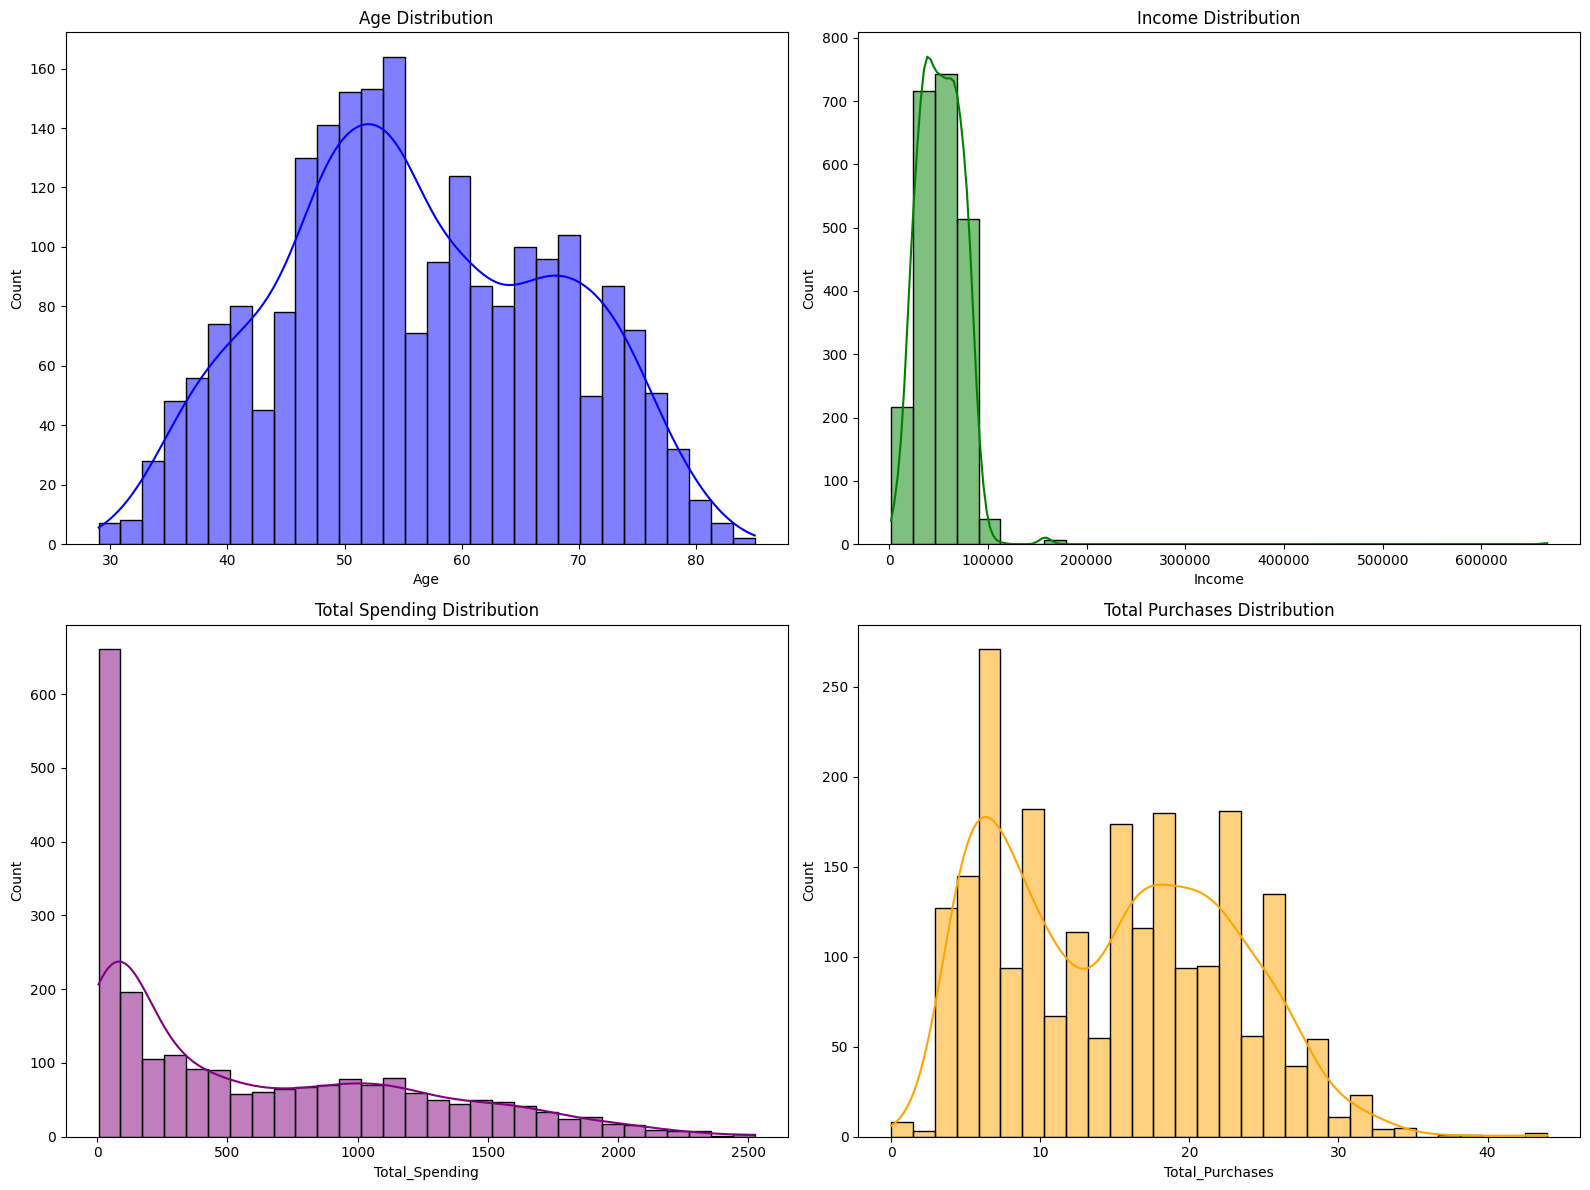

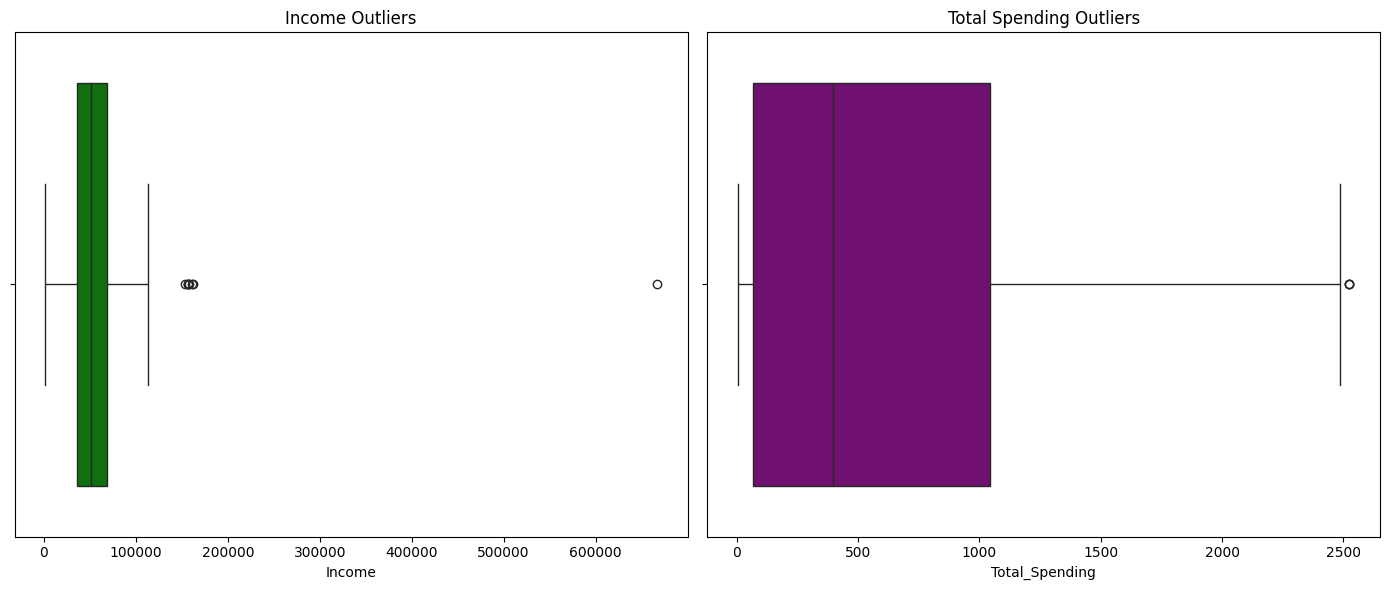

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Summary Statistics ---
print("Summary statistics for numeric variables:\n")
display(df[['Age','Income','Total_Spending','Total_Purchases']].describe())

print("\nSummary statistics for campaign responses:\n")
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                 'AcceptedCmp4','AcceptedCmp5','Response']
display(df[campaign_cols].sum())

# --- 2. Distribution Plots ---
plt.figure(figsize=(16,12))

# Age
plt.subplot(2,2,1)
sns.histplot(df['Age'], bins=30, kde=True, color='blue')
plt.title("Age Distribution")

# Income
plt.subplot(2,2,2)
sns.histplot(df['Income'], bins=30, kde=True, color='green')
plt.title("Income Distribution")

# Total Spending
plt.subplot(2,2,3)
sns.histplot(df['Total_Spending'], bins=30, kde=True, color='purple')
plt.title("Total Spending Distribution")

# Total Purchases
plt.subplot(2,2,4)
sns.histplot(df['Total_Purchases'], bins=30, kde=True, color='orange')
plt.title("Total Purchases Distribution")

plt.tight_layout()
plt.show()

# --- 3. Boxplots for Outlier Detection ---
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x=df['Income'], color='green')
plt.title("Income Outliers")

plt.subplot(1,2,2)
sns.boxplot(x=df['Total_Spending'], color='purple')
plt.title("Total Spending Outliers")

plt.tight_layout()
plt.show()

99th Percentile Income Cap: 94440.31999999999
99th Percentile Spending Cap: 2126.0


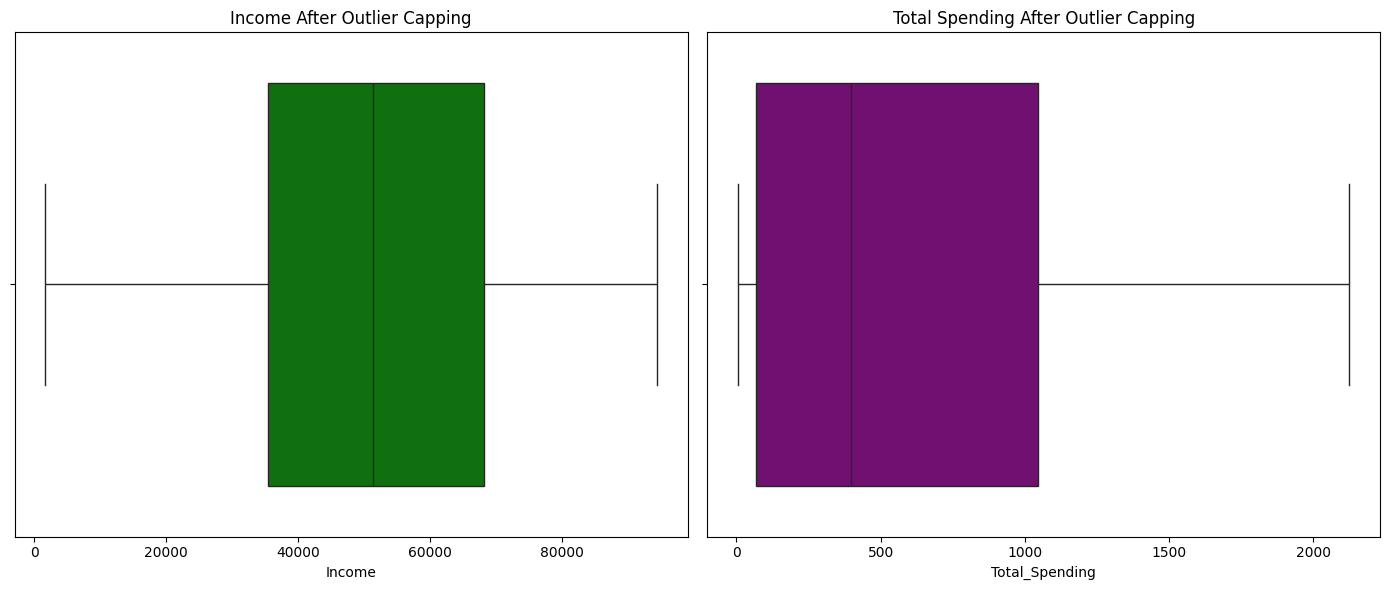


Updated Summary Statistics:


,Income,Total_Spending
count,2237.000000,2237.000000
mean,51751.276141,603.976755
std,20651.067028,596.968272
min,1730.000000,5.000000
25%,35523.000000,69.000000
50%,51373.000000,396.000000
75%,68281.000000,1045.000000
max,94440.320000,2126.000000


In [6]:
# --- Outlier Treatment: Cap Income and Total_Spending at 99th percentile ---

# Define capping thresholds
income_cap = df['Income'].quantile(0.99)
spending_cap = df['Total_Spending'].quantile(0.99)

print("99th Percentile Income Cap:", income_cap)
print("99th Percentile Spending Cap:", spending_cap)

# Apply capping
df['Income'] = np.where(df['Income'] > income_cap, income_cap, df['Income'])
df['Total_Spending'] = np.where(df['Total_Spending'] > spending_cap, spending_cap, df['Total_Spending'])

# Re-check boxplots after capping
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x=df['Income'], color='green')
plt.title("Income After Outlier Capping")

plt.subplot(1,2,2)
sns.boxplot(x=df['Total_Spending'], color='purple')
plt.title("Total Spending After Outlier Capping")

plt.tight_layout()
plt.show()

# Double-check descriptive stats again
print("\nUpdated Summary Statistics:")
display(df[['Income','Total_Spending']].describe())


## Task 4: Encoding & Correlation Analysis
- Encode Education (ordinal)
- Encode Marital_Status, Country (one-hot)
- Correlation heatmap

Unique Education values before mapping:
 ['Graduation' 'Phd' '2N Cycle' 'Master' 'Basic']

Education mapping used: {'Basic': 1, '2N Cycle': 2, 'Graduation': 3, 'Master': 4, 'Phd': 5}

Education_Ord value counts:


Education_Ord
1      54
2     201
3    1127
4     370
5     485
Name: count, dtype: int64


Numeric cols used for correlation:
 ['Age', 'Income', 'Total_Spending', 'Total_Purchases', 'Recency', 'NumWebVisitsMonth', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases', 'Total_Children', 'Education_Ord', 'Response', 'Complain']


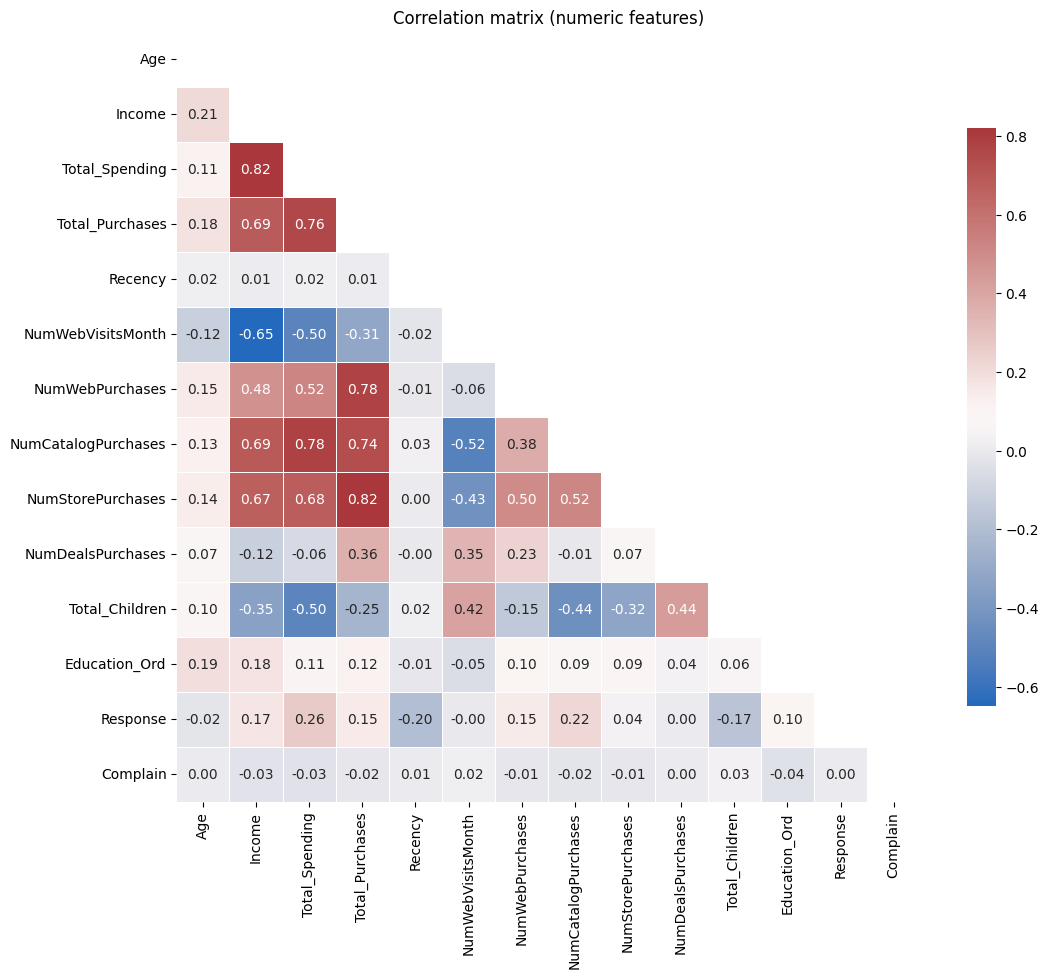


Absolute correlations with Response (campaign acceptance):


Total_Spending         0.264053
NumCatalogPurchases    0.220894
Recency                0.198568
Total_Children         0.169456
Income                 0.168865
Total_Purchases        0.154794
NumWebPurchases        0.148453
Education_Ord          0.098845
NumStorePurchases      0.038855
Age                    0.018424
NumWebVisitsMonth      0.004449
NumDealsPurchases      0.001854
Complain               0.000185
Name: Response, dtype: float64


df_encoded shape: (2237, 47)


In [7]:
# Task 4: Encoding & Correlation Heatmap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make a working copy
df_enc = df.copy()

# --- 1) Clean Education values and ordinal encode ---
# Standardize common variants
df_enc['Education'] = df_enc['Education'].astype(str).str.strip().str.title()

# Define ordered education levels (lowest -> highest)
edu_order = ['Basic', '2N Cycle', 'Graduation', 'Master', 'Phd']  # 'Phd' capitalized to match .title()
# Create mapping (1..5)
education_mapping = {k: i+1 for i, k in enumerate(edu_order)}

# Print unique values first (for your reference)
print("Unique Education values before mapping:\n", df_enc['Education'].unique())

# Map values; unknowns become NaN
df_enc['Education_Ord'] = df_enc['Education'].map(education_mapping)

# If any unmapped values exist, fill with median ordinal
if df_enc['Education_Ord'].isnull().any():
    med = int(df_enc['Education_Ord'].median(skipna=True))
    df_enc['Education_Ord'] = df_enc['Education_Ord'].fillna(med)
    print(f"Filled unmapped education values with median ordinal: {med}")

print("\nEducation mapping used:", education_mapping)
print("\nEducation_Ord value counts:")
display(df_enc['Education_Ord'].value_counts().sort_index())

# --- 2) One-hot encode Marital_Status and Country ---
# Clean strings
df_enc['Marital_Status'] = df_enc['Marital_Status'].astype(str).str.strip().str.title()
df_enc['Country'] = df_enc['Country'].astype(str).str.strip().str.upper()

# One-hot (drop_first to avoid perfect multicollinearity)
marital_dummies = pd.get_dummies(df_enc['Marital_Status'], prefix='Marital', drop_first=True)
country_dummies = pd.get_dummies(df_enc['Country'], prefix='Country', drop_first=True)

# Concatenate to df_enc
df_enc = pd.concat([df_enc, marital_dummies, country_dummies], axis=1)

# --- 3) Select numeric columns for correlation matrix ---
# Choose numeric features of interest (add/remove if you want)
numeric_cols = [
    'Age','Income','Total_Spending','Total_Purchases','Recency',
    'NumWebVisitsMonth','NumWebPurchases','NumCatalogPurchases','NumStorePurchases',
    'NumDealsPurchases','Total_Children','Education_Ord','Response','Complain'
]
# Keep only those that exist to avoid KeyError
numeric_cols = [c for c in numeric_cols if c in df_enc.columns]

print("\nNumeric cols used for correlation:\n", numeric_cols)

# Compute correlation matrix
corr = df_enc[numeric_cols].corr()

# --- 4) Plot correlation heatmap (masked upper triangle) ---
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='vlag', linewidths=0.5, cbar_kws={"shrink": .75})
plt.title("Correlation matrix (numeric features)")
plt.show()

# --- 5) Optional: show top correlations with Response (campaign acceptance) ---
resp_corr = corr['Response'].drop('Response').abs().sort_values(ascending=False)
print("\nAbsolute correlations with Response (campaign acceptance):")
display(resp_corr)

# Prepare final encoded dataframe for downstream tasks
df_encoded = df_enc.copy()  # this contains ordinal + one-hot vars + originals
print("\ndf_encoded shape:", df_encoded.shape)

## Task 5: Hypothesis Testing
H1: Older customers prefer in-store  
H2: Customers with children prefer online  
H3: Store sales cannibalized by other channels  
H4: USA vs Rest total purchases


=== NumStorePurchases: Older vs Younger ===
Means: 6.360560093348892 5.4427536231884055
Std devs: 3.1714237588016485 3.2512035520386746
Levene test p=0.4739
Welch t-test: t=6.590, p=0.0000 (significant)
Cohen's d=0.285
Mann-Whitney U: p=0.0000 (significant)


C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\1875285730.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AgeGroup', y='NumStorePurchases', data=df, palette='Set2')


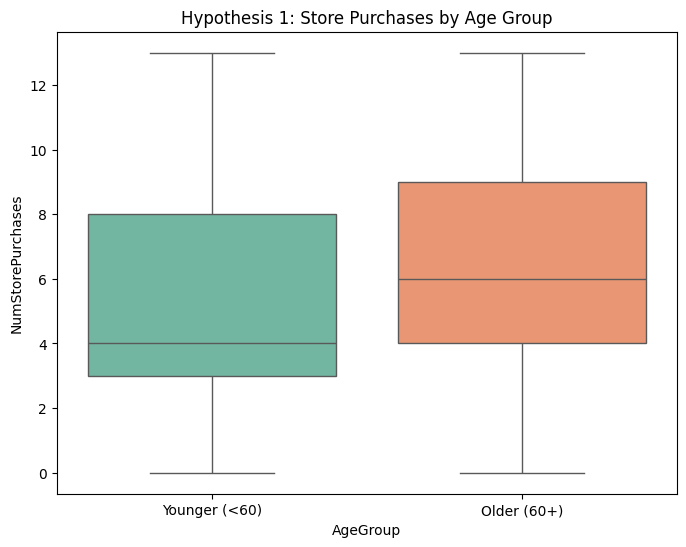


=== NumWebPurchases: Children vs NoChildren ===
Means: 3.965 4.39403453689168
Std devs: 2.8799233885995346 2.4852069663253387
Levene test p=0.0000
Welch t-test: t=-3.517, p=0.0005 (significant)
Cohen's d=-0.155
Mann-Whitney U: p=0.0000 (significant)


C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\1875285730.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HasChildren', y='NumWebPurchases', data=df, palette='Set1')


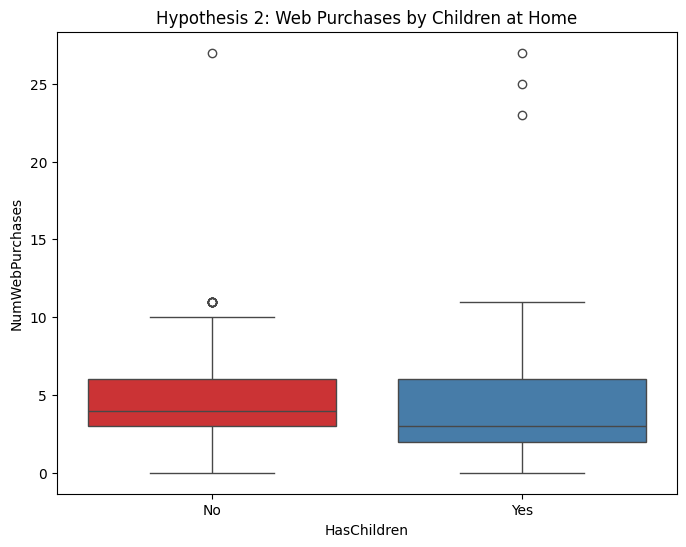


=== Hypothesis 3: Cannibalization check ===
Pearson r=0.615, p=0.0000
Spearman rho=0.737, p=0.0000
Significant positive correlation -> channels complement each other.


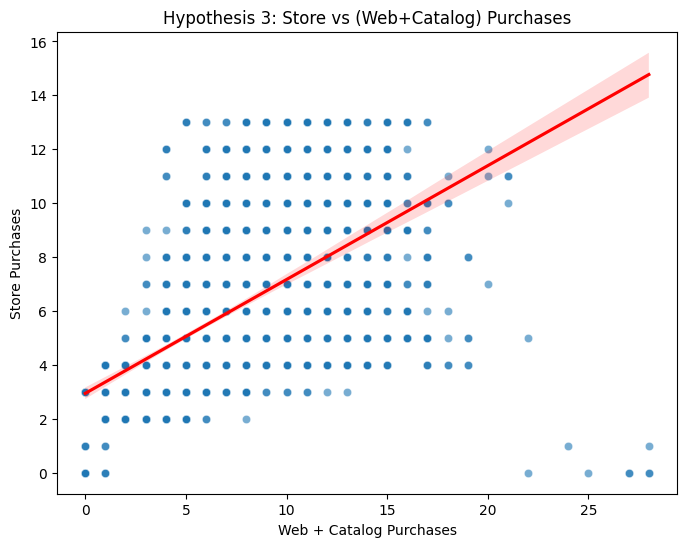


=== Total_Purchases: USA vs Rest ===
Means: 16.155963302752294 14.804981203007518
Std devs: 8.164029406291295 7.64700983254593
Levene test p=0.9367
Welch t-test: t=1.690, p=0.0937 (ns)
Cohen's d=0.176
Mann-Whitney U: p=0.1170 (ns)


C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\1875285730.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CountryGroup', y='Total_Purchases', data=df, palette='Set3')


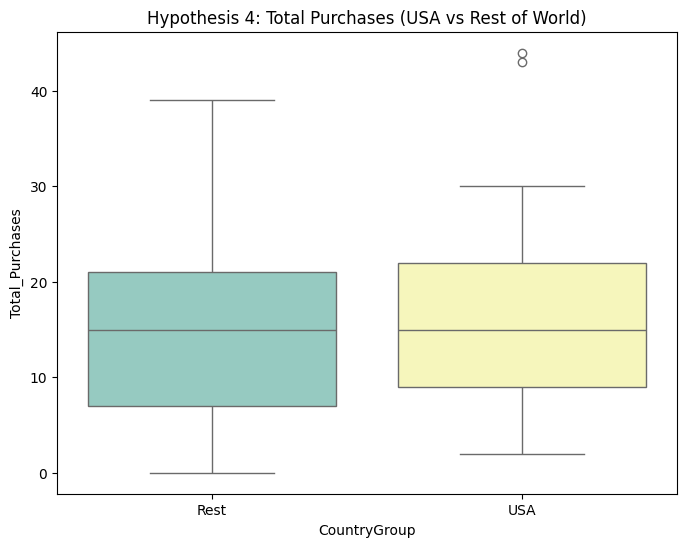


--- Hypothesis Testing Summary ---
H1: Older customers store purchases -> {'mean1': np.float64(6.360560093348892), 'mean2': np.float64(5.4427536231884055), 't_p': np.float64(5.7125226594301816e-11), 'mw_p': np.float64(8.328837302101679e-16), 'cohen_d': np.float64(0.28495505077900296)}
H2: Children vs No children online purchases -> {'mean1': np.float64(3.965), 'mean2': np.float64(4.39403453689168), 't_p': np.float64(0.00045064029164492824), 'mw_p': np.float64(5.065928129082563e-08), 'cohen_d': np.float64(-0.15470036718480706)}
H3: Store vs Other correlation -> Pearson r= 0.6152525182104932 p= 3.8062645496452166e-233
H4: USA vs Rest total purchases -> {'mean1': np.float64(16.155963302752294), 'mean2': np.float64(14.804981203007518), 't_p': np.float64(0.0936507459549608), 'mw_p': np.float64(0.11703401699069263), 'cohen_d': np.float64(0.17607432487187064)}


In [9]:
# ---------------- Task 5: Hypothesis Testing ----------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

alpha = 0.05

# --- Helper: Cohen's d for independent samples ---
def cohens_d(a, b):
    na, nb = len(a), len(b)
    ma, mb = np.mean(a), np.mean(b)
    sa2, sb2 = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled_sd = np.sqrt(((na - 1)*sa2 + (nb - 1)*sb2) / (na + nb - 2)) if (na+nb-2)>0 else np.nan
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (ma - mb) / pooled_sd

# --- Helper: Two-group comparison (t-test + Mann-Whitney + effect size) ---
def compare_groups(x, y, varname, group_names=('A','B')):
    x = np.asarray(x.dropna())
    y = np.asarray(y.dropna())
    print(f"\n=== {varname}: {group_names[0]} vs {group_names[1]} ===")
    print("Means:", np.mean(x), np.mean(y))
    print("Std devs:", np.std(x, ddof=1), np.std(y, ddof=1))
    
    # Levene test
    lev_stat, lev_p = stats.levene(x, y)
    print(f"Levene test p={lev_p:.4f}")
    
    # Welch t-test
    t_stat, t_p = stats.ttest_ind(x, y, equal_var=False)
    print(f"Welch t-test: t={t_stat:.3f}, p={t_p:.4f} {'(significant)' if t_p<alpha else '(ns)'}")
    
    # Effect size
    d = cohens_d(x, y)
    print(f"Cohen's d={d:.3f}")
    
    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(x, y, alternative='two-sided')
    print(f"Mann-Whitney U: p={u_p:.4f} {'(significant)' if u_p<alpha else '(ns)'}")
    
    return {'mean1': np.mean(x), 'mean2': np.mean(y), 't_p': t_p, 'mw_p': u_p, 'cohen_d': d}

# =============================================================
# Hypothesis 1: Older customers prefer in-store shopping
# =============================================================
df['AgeGroup'] = np.where(df['Age'] >= 60, 'Older (60+)', 'Younger (<60)')

res1 = compare_groups(
    df.loc[df['AgeGroup']=='Older (60+)', 'NumStorePurchases'],
    df.loc[df['AgeGroup']=='Younger (<60)', 'NumStorePurchases'],
    varname="NumStorePurchases", group_names=('Older','Younger')
)

plt.figure(figsize=(8,6))
sns.boxplot(x='AgeGroup', y='NumStorePurchases', data=df, palette='Set2')
plt.title("Hypothesis 1: Store Purchases by Age Group")
plt.show()

# =============================================================
# Hypothesis 2: Customers with children prefer online shopping
# =============================================================
df['HasChildren'] = np.where(df['Total_Children'] > 0, 'Yes', 'No')

res2 = compare_groups(
    df.loc[df['HasChildren']=='Yes', 'NumWebPurchases'],
    df.loc[df['HasChildren']=='No', 'NumWebPurchases'],
    varname="NumWebPurchases", group_names=('Children','NoChildren')
)

plt.figure(figsize=(8,6))
sns.boxplot(x='HasChildren', y='NumWebPurchases', data=df, palette='Set1')
plt.title("Hypothesis 2: Web Purchases by Children at Home")
plt.show()

# =============================================================
# Hypothesis 3: Store sales cannibalized by other channels
# =============================================================
other_channels = df['NumWebPurchases'] + df['NumCatalogPurchases']
store = df['NumStorePurchases']

pearson_r, pearson_p = stats.pearsonr(store, other_channels)
spearman_r, spearman_p = stats.spearmanr(store, other_channels)

print("\n=== Hypothesis 3: Cannibalization check ===")
print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.4f}")
print(f"Spearman rho={spearman_r:.3f}, p={spearman_p:.4f}")
if pearson_p < alpha and pearson_r < 0:
    print("Evidence of cannibalization (negative correlation).")
elif pearson_p < alpha and pearson_r > 0:
    print("Significant positive correlation -> channels complement each other.")
else:
    print("No significant correlation found.")

plt.figure(figsize=(8,6))
sns.scatterplot(x=other_channels, y=store, alpha=0.6)
sns.regplot(x=other_channels, y=store, scatter=False, color='red')
plt.title("Hypothesis 3: Store vs (Web+Catalog) Purchases")
plt.xlabel("Web + Catalog Purchases")
plt.ylabel("Store Purchases")
plt.show()

# =============================================================
# Hypothesis 4: USA vs Rest of World purchases
# =============================================================
df['CountryGroup'] = np.where(df['Country'].str.upper()=='US', 'USA', 'Rest')

res4 = compare_groups(
    df.loc[df['CountryGroup']=='USA', 'Total_Purchases'],
    df.loc[df['CountryGroup']=='Rest', 'Total_Purchases'],
    varname="Total_Purchases", group_names=('USA','Rest')
)

plt.figure(figsize=(8,6))
sns.boxplot(x='CountryGroup', y='Total_Purchases', data=df, palette='Set3')
plt.title("Hypothesis 4: Total Purchases (USA vs Rest of World)")
plt.show()

# =============================================================
# Summary of Hypotheses
# =============================================================
print("\n--- Hypothesis Testing Summary ---")
print("H1: Older customers store purchases ->", res1)
print("H2: Children vs No children online purchases ->", res2)
print("H3: Store vs Other correlation -> Pearson r=", pearson_r, "p=", pearson_p)
print("H4: USA vs Rest total purchases ->", res4)

## Hypothesis 1 — Older vs Younger (NumStorePurchases)

Result: Older (60+) mean = 6.36 vs Younger mean = 5.44.

Welch t-test p ≪ 0.001, Mann–Whitney p ≪ 0.001 → statistically significant.

Cohen’s d = 0.285 → small-to-moderate effect.

Plot: boxplot shows older customers shift upward in store purchases.
→ Conclusion: Older customers do buy more in-store (modest effect). Good evidence.

##  2 — Children vs No Children (NumWebPurchases)

Result: With children mean = 3.97, No children = 4.39.

Welch t-test p ≈ 0.00045, Mann–Whitney p ≪ 0.001 → statistically significant, direction opposite to initial assumption.

Cohen’s d = -0.155 → very small effect (practically small).

Plot: boxplot confirms medians slightly lower for households with children.
→ Conclusion: Households with children purchase slightly less via web in this dataset (small effect). Worth investigating covariates (age, income, time constraints, product mix).

## Hypothesis 3 — Cannibalization (Store vs Web+Catalog)

Result: Pearson r = +0.615, Spearman rho = +0.737, both p ≪ 0.001.

Plot: scatter + regression line shows a clear positive relationship.
→ Conclusion: No evidence of cannibalization. Channels move together — multichannel buyers buy across channels.

## Hypothesis 4 — USA vs Rest (Total_Purchases)

Result: USA mean = 16.16, Rest = 14.80.

Welch t-test p ≈ 0.0937, Mann–Whitney p ≈ 0.117 → not significant at α=0.05.

Cohen’s d = 0.176 → small, non-significant effect.

Plot: boxplot shows similar distributions with US a bit higher but overlapping.
→ Conclusion: No statistically significant difference between US and rest in total purchases.

## Business takeaways (actionable)

In-store focus for older customers — promote in-store experiences, loyalty events, or senior-targeted promos.

Re-check assumptions about families — families do not necessarily prefer web purchases here; consider surveying for reasons (product bundle needs, payment options, delivery constraints).

Lean into multichannel campaigns — customers who buy in one channel often buy in others; coordinated cross-channel offers are promising.

No need to prioritize US over other countries on purchases — keep an international campaign balance.

## Task 6 — Visualization-Based Business Insights
- Top vs Lowest revenue products
- Age vs campaign acceptance
- Country with highest acceptance
- Children vs spending
- Education of complainers

C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\3470639180.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_revenue.values, y=product_revenue.index, palette='viridis')


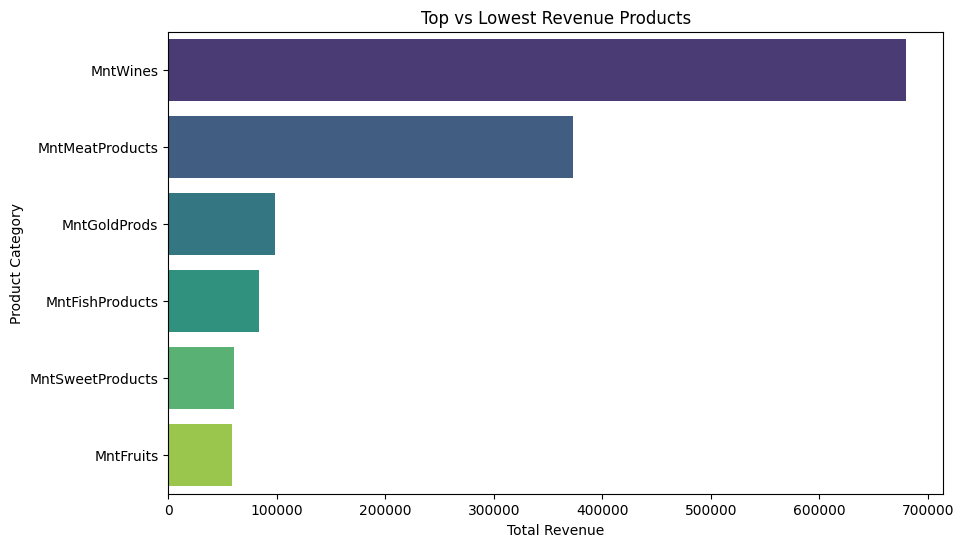

C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\3470639180.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Response', y='Age', data=df, jitter=True, alpha=0.5, palette='Set2')


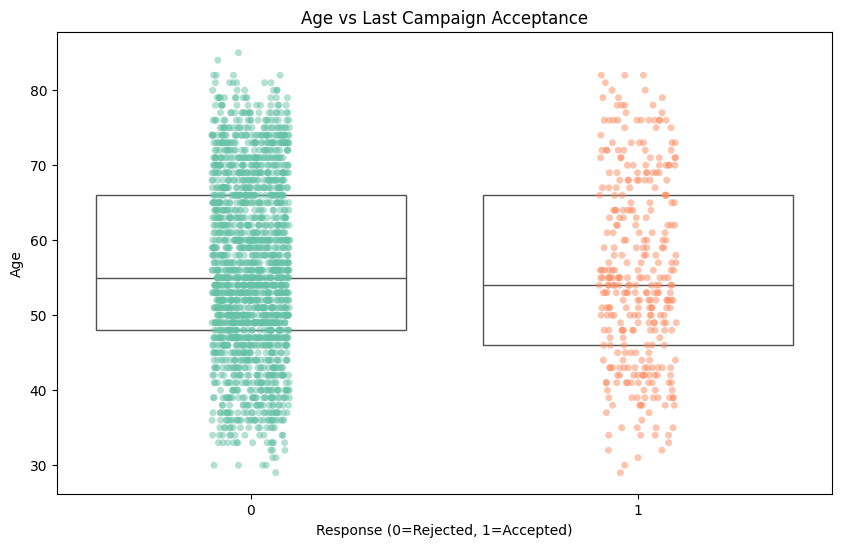

C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\3470639180.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_acceptance.index, y=country_acceptance.values, palette='coolwarm')


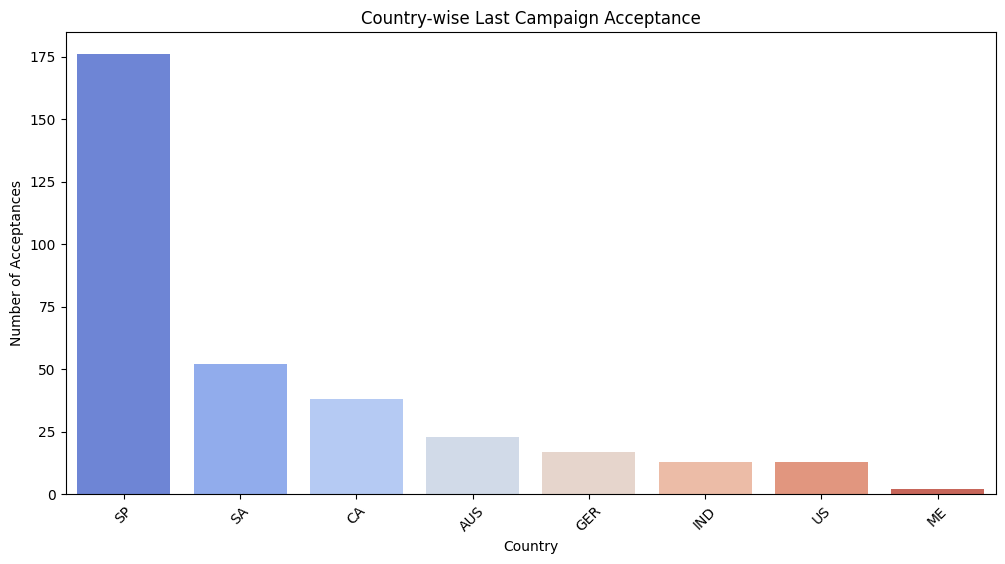

C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\3470639180.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total_Children', y='Total_Spending', data=df, palette='Set3')


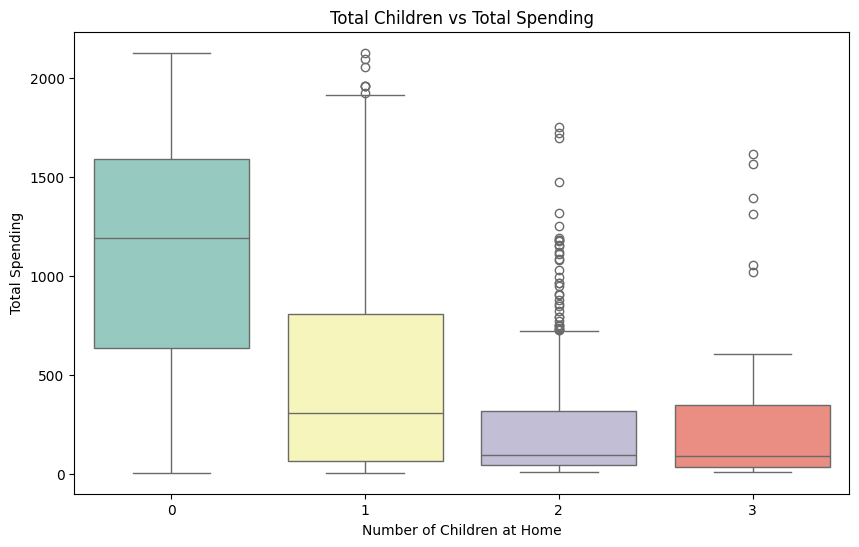

C:\Users\viswa\AppData\Local\Temp\ipykernel_30748\3470639180.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=complain_edu.index, y=complain_edu.values, palette='magma')


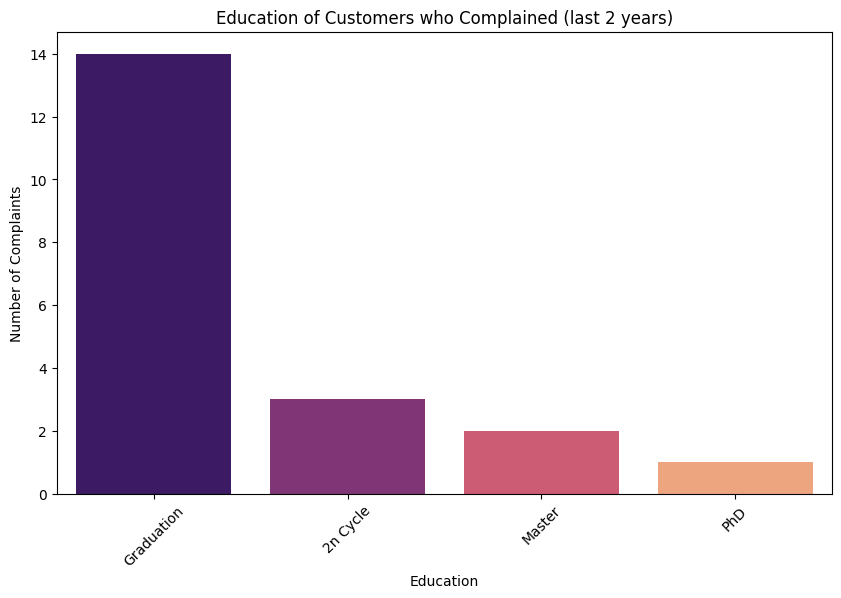

In [10]:
# ---------------- Task 6: Visualization-Based Business Insights ----------------
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top vs Lowest Revenue Products
product_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
product_revenue = df[product_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=product_revenue.values, y=product_revenue.index, palette='viridis')
plt.title("Top vs Lowest Revenue Products")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.show()

# 2. Age vs Last Campaign Acceptance
plt.figure(figsize=(10,6))
sns.stripplot(x='Response', y='Age', data=df, jitter=True, alpha=0.5, palette='Set2')
sns.boxplot(x='Response', y='Age', data=df, showcaps=False, boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0})
plt.title("Age vs Last Campaign Acceptance")
plt.xlabel("Response (0=Rejected, 1=Accepted)")
plt.ylabel("Age")
plt.show()

# 3. Country with Highest Campaign Acceptance
country_acceptance = df.groupby('Country')['Response'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=country_acceptance.index, y=country_acceptance.values, palette='coolwarm')
plt.title("Country-wise Last Campaign Acceptance")
plt.xlabel("Country")
plt.ylabel("Number of Acceptances")
plt.xticks(rotation=45)
plt.show()

# 4. Children at Home vs Total Expenditure
plt.figure(figsize=(10,6))
sns.boxplot(x='Total_Children', y='Total_Spending', data=df, palette='Set3')
plt.title("Total Children vs Total Spending")
plt.xlabel("Number of Children at Home")
plt.ylabel("Total Spending")
plt.show()

# 5. Education of Customers who Complained
complain_edu = df[df['Complain']==1]['Education'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=complain_edu.index, y=complain_edu.values, palette='magma')
plt.title("Education of Customers who Complained (last 2 years)")
plt.xlabel("Education")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()


## Quick results (from Task 6 plots)

## 1) Top vs Lowest Revenue Products

Top: MntWines (by a large margin).

2nd: MntMeatProducts.

Lowest: MntFruits (then MntSweetProducts, MntFishProducts, MntGoldProds).

## 2) Age vs Last Campaign Acceptance

Acceptance (Response = 1) occurs across ages; medians for accepted vs rejected are very similar.

No strong age-driven separation for the last campaign (matches low correlation earlier).

## 3) Country with Highest Campaign Acceptance

Top country: SP (highest number of acceptances).

Next highest: SA, CA, AUS, GER, IND, US, ME (in that order on the barplot).

## 4) Children at Home vs Total Expenditure

Households with 0 children show the highest median and widest spending distribution.

As children count increases, median spending drops substantially (and distributions shift lower).

There are outliers (some high spenders even with children), but typical trend: fewer children → higher spending.

## 5) Education of Customers who Complained

Most complaints come from customers with Graduation level (followed by 2N Cycle, Master, PhD).

Absolute complaint counts are small, but concentrated in Graduates.

## Business interpretations & recommended actions

## Product focus & promotions

Prioritize marketing and inventory for Wines and Meat (they drive most revenue).

Create premium wine bundles + meat-pairing promotions for high-spending segments.

## Customer targeting

Target childless customers with premium/up-sell campaigns — they have higher spending.

Families with children purchase differently (lower online purchases & lower spending) — test family bundles, convenient delivery/time-saving offers, or in-store promotions for them.

## Channel strategy

Channels complement each other (Task 5). Use cross-channel campaigns (catalog + in-store + web) rather than treating channels as competing.

## Geo targeting

Focus acquisition budget and localized creatives on SP and top-acceptance countries (SA, CA, AUS) — they show better campaign conversion.

The US is not the dominant acceptance market in this dataset — don’t over-allocate there without further ROI analysis.

## Customer experience / complaints

Most complaints are from Graduates — run a short survey or dig into complaint reasons for that segment (product, delivery, returns). Fixes here could improve retention and lifetime value.

## Task 7 — Summary Report

## 📊 Final Summary Report — Marketing Campaigns Analysis

## 🎯 Objective
The project aimed to analyze customer demographics, spending behavior, and campaign responses to identify key factors influencing **customer acquisition**.  
We applied **EDA, hypothesis testing, and business insights visualization** to guide marketing strategy.

---

## ✅ Key Findings

### 1. Customer Demographics
- Average customer age: **56 years** (majority between 45–70).  
- Income: Avg ~₹52K, with realistic upper bound capped at ~₹94K (after outlier treatment).  
- Customers without children tend to spend significantly more than those with children.

### 2. Spending & Purchases
- **Top products:** Wines (highest by far), followed by Meat.  
- **Lowest products:** Fruits, Sweets, Fish, Gold.  
- Average customer total spending ~₹600, total purchases ~15.  

### 3. Campaign Responses
- Acceptance rates are low: last campaign acceptance only **~15%**.  
- Stronger acceptance correlated with:
  - Higher spending (corr=0.26)  
  - Catalog buyers (corr=0.22)  
  - Higher income & children households (small effect).  

### 4. Hypothesis Testing
- **H1:** Older (60+) buy significantly more in-store (p<0.001, small-to-moderate effect).  
- **H2:** Households with children do **not** prefer online shopping (they buy slightly less online, p<0.001).  
- **H3:** No cannibalization — store & online/catalog purchases show **positive correlation** (r=0.62).  
- **H4:** USA vs Rest → No significant difference in purchases (p>0.09).  

### 5. Business Insights
- Focus campaigns on **wine & meat buyers** (biggest revenue).  
- Design premium campaigns for **childless customers** (they spend more).  
- Use **cross-channel promotions** instead of isolating channels (buyers are multichannel).  
- **SP** and a few other countries (SA, CA, AUS) dominate campaign acceptance → focus international targeting there.  
- Investigate complaints from **Graduation-level customers**, who dominate complaint counts.

---

## 📌 Strategic Recommendations
1. **Product Marketing:** Bundle wines + meats for premium campaigns.  
2. **Customer Segmentation:** Target high-income, childless customers for acquisition.  
3. **Channel Strategy:** Strengthen catalog + in-store integration (synergistic channels).  
4. **Geo Strategy:** Increase investment in SP, SA, CA, AUS markets.  
5. **Customer Experience:** Address pain points of Graduates through surveys & service improvements.

---

## 🧾 Conclusion
This analysis provides a data-backed framework for improving **customer acquisition and campaign performance**.  
The company should **double down on high-value segments** while addressing pain points of underperforming ones.  

---


In [12]:
# Save cleaned datase
df.to_csv("marketing_data_cleaned.csv", index=False)

# Save encoded dataset
df_encoded.to_csv("marketing_data_encoded.csv", index=False)

# Export summary stats & correlations
with open("summary_report.txt", "w") as f:
    f.write("Final Summary Report — Marketing Campaigns Analysis\n")
    f.write("Key Findings & Recommendations documented in notebook.\n")

print("✅ Cleaned datasets and summary report saved for submission.")

✅ Cleaned datasets and summary report saved for submission.
